#Cardiovascular Disease Prediction Using Machine Learning

This project uses Machine Learning algorithms to predict Cardiovascular Disease based on the selected patient-related features.

The project includes data preprocessing, exploratory data analysis,machine learning model training, model comparison,evaluation,and an interactive prediction interface using Gradio.

Disclaimer: This project is for educational and demonstration purposes only. The Model prediction is not a medical diagnosis.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


## 1. Dataset Loading and Understanding


df = pd.read_csv("/content/cardio_train.csv",sep=';')
print(df.head())
print(df.shape)
print(df.info())



   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null

## 2. Data Preprocessing

In [ ]:
print(df.isnull().sum())
df = df.drop_duplicates()
df["age"] = (df["age"]/365).astype(int)
df = df.drop("id",axis=1)
print(df.head())


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   50       2     168    62.0    110     80            1     1      0     0   
1   55       1     156    85.0    140     90            3     1      0     0   
2   51       1     165    64.0    130     70            3     1      0     0   
3   48       2     169    82.0    150    100            1     1      0     0   
4   47       1     156    56.0    100     60            1     1      0     0   

   active  cardio  
0       1       0  
1       1       1  
2       0       1  
3       1       1  
4       0       0  


## 3. Exploratory Data Analysis



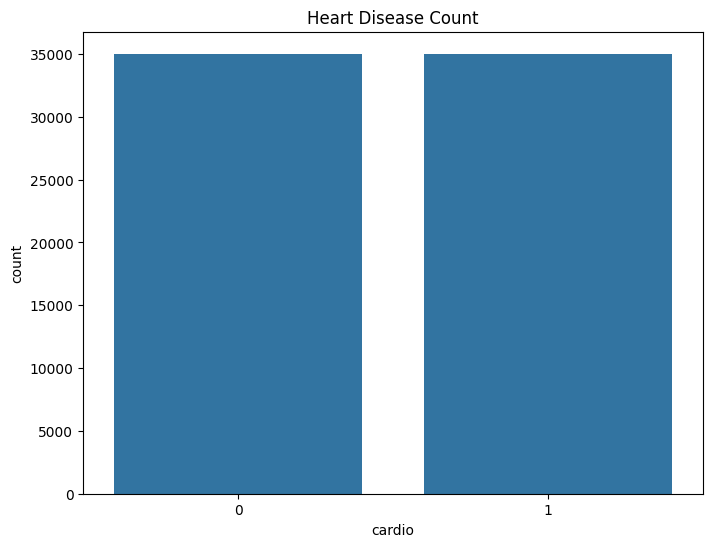

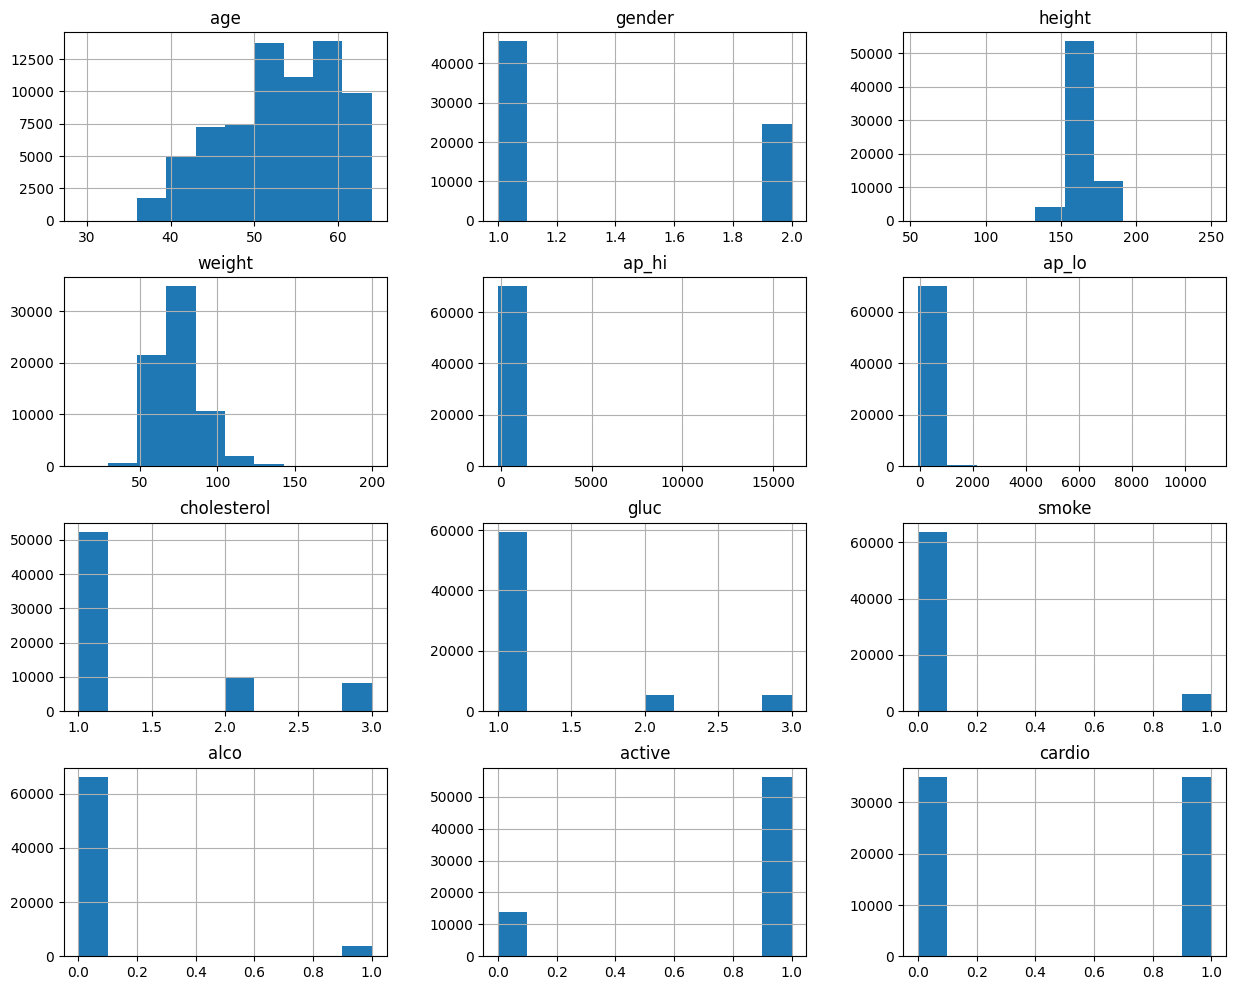

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="cardio",data=df)
plt.title("Heart Disease Count")
plt.show()

df.hist(figsize=(15,12))
plt.show()

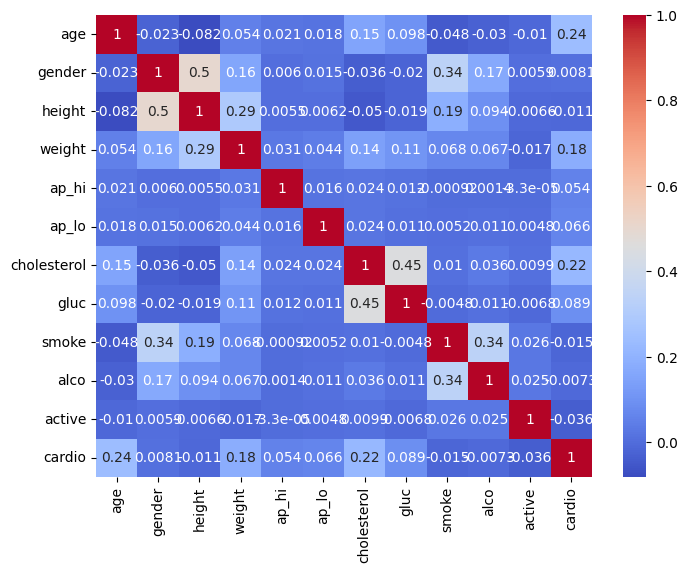

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()



## 4. Machine Learning Model Training



In [ ]:
X = df.drop("cardio",axis=1)
y = df["cardio"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr =LogisticRegression(max_iter = 1000)
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test,pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.7227142857142858


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test,pred_knn)
print("KNN Accuracy:", acc_knn)


KNN Accuracy: 0.6532857142857142


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test,pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.6363571428571428


In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test,pred_rf)
print("Random Forest Accuracy:",acc_rf)

Random Forest Accuracy: 0.7086428571428571


In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm = SVC(kernel='linear')
svm.fit(X_train,y_train)
pred_svm = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test,pred_svm)
print("SVM Accuracy:",svm_accuracy)
print("SVM Accuracy(%):",svm_accuracy*100)


SVM Accuracy: 0.7263571428571428
SVM Accuracy(%): 72.63571428571429


## 5. Model Comparison and Results

                 Model  Accuracy
0  Logistic Regression  0.722714
1                  KNN  0.653286
2        Decision Tree  0.636357
3        Random Forest  0.708643
4                  SVM  0.732286


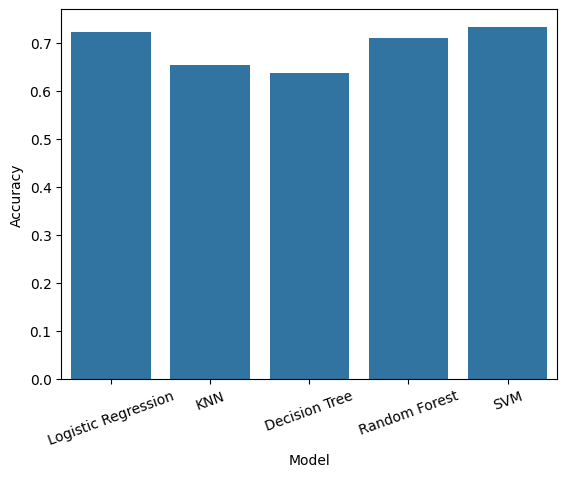

In [25]:
accuracy = pd.DataFrame({"Model":["Logistic Regression","KNN","Decision Tree","Random Forest","SVM"],"Accuracy":[acc_lr,acc_knn,acc_dt,acc_rf,acc_svm]})
print(accuracy)
sns.barplot(data = accuracy,x = "Model", y = "Accuracy")
plt.xticks(rotation = 20)
plt.show()

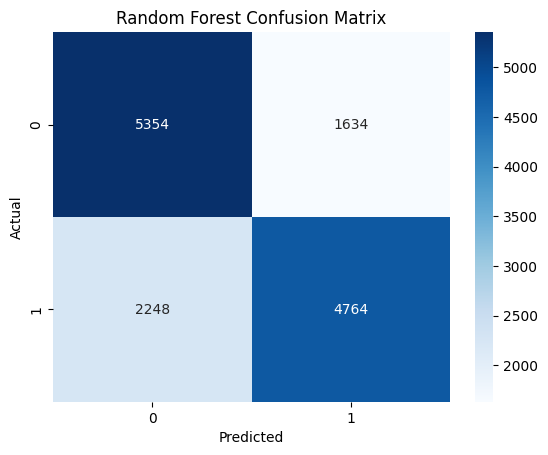

In [26]:
cm = confusion_matrix(y_test,pred_lr)
sns.heatmap(cm,annot=True,fmt="d",cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [27]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      6988
           1       0.71      0.71      0.71      7012

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



## 6. SVM Model Evaluation

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.75      6988
           1       0.77      0.64      0.70      7012

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.72     14000
weighted avg       0.73      0.73      0.72     14000



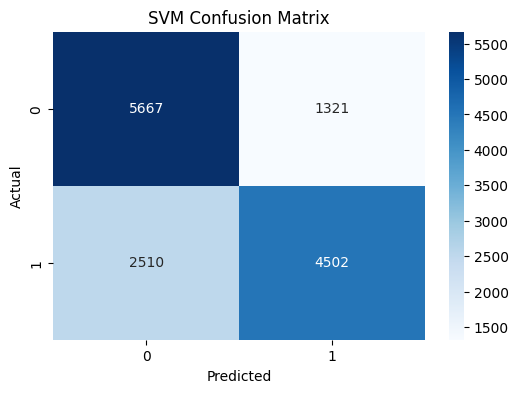

In [28]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("SVM Classification Report:")
print(classification_report(y_test,pred_svm))
cm = confusion_matrix(y_test,pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [29]:
print(X.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [30]:
import numpy as np
patient = np.array([[50,1,170,70,120,80,1,1,0,0,1]])
patient_scaled = scaler.transform(patient)
prediction = svm.predict(patient_scaled)
print("SVM Prediction:",prediction[0])

SVM Prediction: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
patient = pd.DataFrame([[50,1,170,70,120,80,1,1,0,0,1]],columns=X.columns)
patient_scaled = scaler.transform(patient)
prediction = svm.predict(patient_scaled)
print("SVM Prediction:",prediction[0])

SVM Prediction: 0


In [32]:
if prediction[0] == 1:
  print("Prediction: Cardiovascular disease detected.")
else:
  print("Prediction: No cardiovascular disease detected.")

Prediction: No cardiovascular disease detected.


In [33]:
age = int(input("Enter age: "))
gender = int(input("Enter gender: "))
height = int(input("Enter height: "))
weight = int(input("Enter weight: "))
ap_hi = int(input("Enter Systolic blood pressure: "))
ap_lo = int(input("Enter Diastolic blood pressure: "))
cholesterol = int(input("Enter Cholesterol (1,2,3): "))
gluc = int(input("Enter Glucose (1,2,3): "))
smoke = int(input("Enter Smoking (0 or 1): "))
alco = int(input("Enter Alcohol (0=No 1=Yes): "))
active = int(input("Enter Physically Active (0=No, 1=Yes): "))
patient = np.array([[age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active]])
patient_scaled = scaler.transform(patient)
prediction = svm.predict(patient_scaled)
if prediction[0] ==1:
  print("Prediction: Cardiovascular Disease Detected.")
else:
  print("Prediction: No Cardiovascular Disease Deetected.")

Enter age: 50
Enter gender: 1
Enter height: 150
Enter weight: 78
Enter Systolic blood pressure: 120
Enter Diastolic blood pressure: 80
Enter Cholesterol (1,2,3): 3
Enter Glucose (1,2,3): 2
Enter Smoking (0 or 1): 0
Enter Alcohol (0=No 1=Yes): 0
Enter Physically Active (0=No, 1=Yes): 1
Prediction: Cardiovascular Disease Detected.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 7. Interactive Prediction Interface

In [34]:
import gradio as gr
print("Gradio installed successfully!")

Gradio installed successfully!


In [35]:
print("SVM:", svm)
print("Scaler:", scaler)
print("Columns:",X.columns.tolist())

SVM: SVC(kernel='linear')
Scaler: StandardScaler()
Columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [36]:
import gradio as gr
def hello(name):
  return "Hello " + name
gr.Interface(fn=hello,inputs=gr.Textbox(label="Enter your name"),
             outputs=gr.Textbox(label="Result")).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9bff758e8d33df39e3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [37]:
import gradio as gr
def predict_disease(age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active):
  patient = pd.DataFrame([[age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active]],columns=X.columns)
  patient_scaled = scaler.transform(patient)
  prediction =svm.predict(patient_scaled)
  if prediction[0] == 1:
    return "Model Prediction: Cardiovascular Disease Detected"
  else:
    return "Model Prediction: No Cardiovascular Disease Detected"
demo = gr.Interface(fn=predict_disease,
                      inputs=[
                          gr.Number(label="Age"),
                          gr.Number(label="Gender"),
                          gr.Number(label="Height"),
                          gr.Number(label="Weight"),
                          gr.Number(label="Systolic BP"),
                          gr.Number(label="Diastolic BP"),
                          gr.Number(label="Cholesterol(1-3)"),
                          gr.Number(label="Glucose(1-3)"),
                          gr.Number(label="Smoking(0/1)"),
                          gr.Number(label="Alcohol(0/1)"),
                          gr.Number(label="Activity(0/1)")
                      ],
                      outputs=gr.Textbox(label="Prediction"),
                      title="Cardiovascular Disease Prediction",description="Enter patient details to get an ML model prediction.")
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63a32d6331df4dad98.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [38]:
import gradio as gr
def predict_disease(age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active):
  patient = pd.DataFrame([[age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active]],columns=X.columns)
  patient_scaled = scaler.transform(patient)
  prediction = svm.predict(patient_scaled)
  if prediction[0] == 1:
    return "Model Prediction: Cardiovascular Disease Detected"
  else:
    return "Model Prediction: No Cardiovascular Disease Detected"
demo = gr.Interface(fn=predict_disease,
       inputs=[
              gr.Number(label="Age"),
              gr.Number(label="Gender"),
              gr.Number(label="Height"),
              gr.Number(label="Weight"),
              gr.Number(label="Systolic BP"),
              gr.Number(label="Diastolic BP"),
              gr.Dropdown(
                  choices=[1,2,3],
                  label="Cholesterol"
              ),
              gr.Dropdown(
                  choices=[1,2,3],
                  label="Glucose"
              ),
              gr.Dropdown(
                  choices=[0,1],
                  label="Smoking (0=No,1=Yes)"
              ),
              gr.Dropdown(
                  choices=[0,1],
                  label="Alcohol (0=No,1=Yes)"
              ),
              gr.Dropdown(
                  choices=[0,1],
                  label="Physical Activity (0=No,1=Yes)"
              )],
                    outputs=gr.Textbox(label="Prediction"),title="Cardiovascular Disease Prediction",description = "Enter the required patient information" "to get a prediction from ML model.")
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8f2c3078db55fadb0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Disclaimer

This project is developed for Educational and Demonstration purposes only.
The prediction generated by this Machine Learning Model should not be considered a medical diagnosis or a substitute for a professional medical advice.

In [39]:
print("Project is working successfully!")

Project is working successfully!
